# 📊 Supermarket Sales — Interactive Dashboard-Style EDA

**Tools:** Python • Pandas • NumPy • Matplotlib • Seaborn • Plotly • Jupyter

This notebook creates a **Power BI-inspired dashboard experience inside Jupyter**. It does not require Power BI, Streamlit, or `app.py`.

### Dashboard sections
- KPI cards: total sales, average transaction, quantity sold, average rating
- Sales by product line
- Sales by city and branch
- Payment and customer analysis
- Monthly sales trend
- Quantity vs sales relationship
- Correlation heatmap
- Interactive Plotly charts with hover and zoom


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from IPython.display import display, HTML

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

In [2]:
df = pd.read_csv("Super Market Sales.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully!
Rows: 8523
Columns: 12


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [3]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


## 2. Data Cleaning & Preparation

In [4]:
data = df.copy()

# Remove duplicate records
data = data.drop_duplicates()

# Fill Item Weight with median
data["Item_Weight"] = data["Item_Weight"].fillna(
    data["Item_Weight"].median()
)

# Fill categorical missing values
data["Outlet_Size"] = data["Outlet_Size"].fillna(
    data["Outlet_Size"].mode()[0]
)

# Clean Item Fat Content
data["Item_Fat_Content"] = data["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

print("Cleaning completed!")

print("\nRemaining missing values:")
display(data.isnull().sum().to_frame("Missing Values"))

Cleaning completed!

Remaining missing values:


,Missing Values
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


# 🎯 3. Executive KPI Dashboard

In [5]:
total_sales = data["Item_Outlet_Sales"].sum()
average_sales = data["Item_Outlet_Sales"].mean()

total_items = data["Item_Identifier"].nunique()
total_outlets = data["Outlet_Identifier"].nunique()

average_mrp = data["Item_MRP"].mean()


def create_kpi(title, value, subtitle):

    return f"""
    <div style="
        width:190px;
        padding:22px;
        margin:8px;
        border-radius:18px;
        background:linear-gradient(135deg,#0f172a,#2563eb);
        color:white;
        text-align:center;
        box-shadow:0 8px 20px rgba(0,0,0,0.2);
        display:inline-block;
        font-family:Arial;
    ">

        <div style="
            font-size:14px;
            opacity:0.8;
        ">
            {title}
        </div>

        <div style="
            font-size:28px;
            font-weight:bold;
            margin:10px 0;
        ">
            {value}
        </div>

        <div style="
            font-size:12px;
            opacity:0.7;
        ">
            {subtitle}
        </div>

    </div>
    """


dashboard = f"""
<div>

{create_kpi(
    "💰 Total Sales",
    f"₹{total_sales/1000000:.2f}M",
    "Total Outlet Sales"
)}

{create_kpi(
    "📊 Average Sales",
    f"₹{average_sales:,.2f}",
    "Average Transaction"
)}

{create_kpi(
    "🛍️ Unique Items",
    f"{total_items:,}",
    "Item Identifiers"
)}

{create_kpi(
    "🏪 Outlets",
    f"{total_outlets:,}",
    "Total Outlets"
)}

{create_kpi(
    "💵 Average MRP",
    f"₹{average_mrp:,.2f}",
    "Average Item MRP"
)}

</div>
"""

display(HTML(dashboard))

## 4. 🏆 Sales by Item Type

In [6]:
import plotly.express as px

# =========================================================
# 1. SALES BY PRODUCT LINE
# =========================================================

if {'Product line', 'Total'}.issubset(df.columns):

    product_sales = (
        df.groupby('Product line', as_index=False)['Total']
        .sum()
        .sort_values('Total', ascending=False)
    )

    fig = px.bar(
        product_sales,
        x='Product line',
        y='Total',
        text_auto='.2s',
        color='Total',
        title='💰 Total Sales by Product Line',
        template='plotly_white'
    )

    fig.update_layout(
        title_x=0.5,
        xaxis_title='',
        yaxis_title='Total Sales'
    )

    fig.update_xaxes(tickangle=-40)

    fig.show()


# =========================================================
# 2. SALES BY ITEM TYPE
# =========================================================

if {'Item_Type', 'Item_Outlet_Sales'}.issubset(df.columns):

    item_sales = (
        df.groupby('Item_Type')['Item_Outlet_Sales']
        .sum()
        .sort_values(ascending=False)
        .reset_index()
    )

    fig = px.bar(
        item_sales,
        x='Item_Type',
        y='Item_Outlet_Sales',
        color='Item_Outlet_Sales',
        text_auto='.2s',
        title='🏆 Total Sales by Item Type',
        template='plotly_white'
    )

    fig.update_layout(
        title_x=0.5,
        xaxis_title='Item Type',
        yaxis_title='Total Sales'
    )

    fig.update_xaxes(tickangle=-40)

    fig.show()

## 5. Interactive Sales Share by Product Line

In [7]:
if {'Product line','Total'}.issubset(df.columns):
    fig = px.pie(product_sales, names='Product line', values='Total', hole=0.45,
                 title='🍩 Sales Share by Product Line', template='plotly_white')
    fig.update_traces(textposition='inside', textinfo='percent+label')
    fig.show()

## 6. 🍩 Sales Share by Item Type

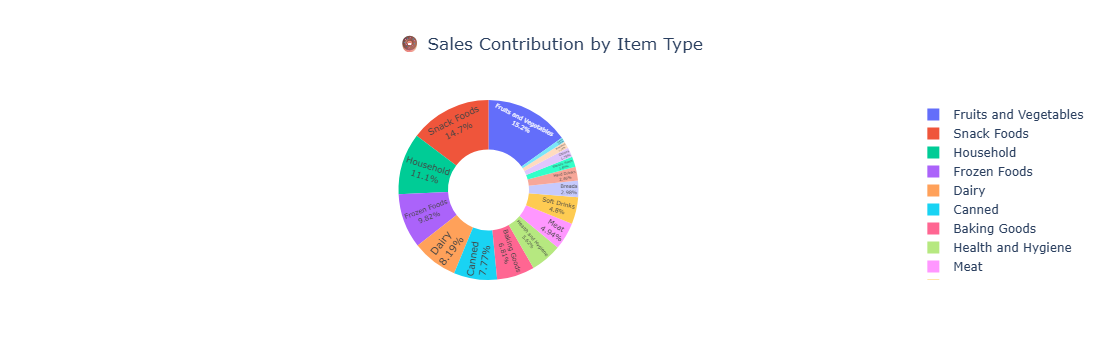

In [8]:
fig = px.pie(
    item_sales,
    names="Item_Type",
    values="Item_Outlet_Sales",
    hole=0.45,
    title="🍩 Sales Contribution by Item Type",
    template="plotly_white"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.update_layout(title_x=0.5)

fig.show()

## 7. Outlet Type Sales

In [9]:
outlet_sales = (
    data.groupby("Outlet_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    outlet_sales,
    x="Outlet_Type",
    y="Item_Outlet_Sales",
    color="Outlet_Type",
    text_auto=".2s",
    title="🏪 Sales by Outlet Type",
    template="plotly_white"
)

fig.update_layout(
    title_x=0.5,
    showlegend=False
)

fig.show()

## 8. Outlet Type Contribution

In [10]:
fig = px.pie(
    outlet_sales,
    names="Outlet_Type",
    values="Item_Outlet_Sales",
    hole=0.5,
    title="🥧 Outlet Type Sales Contribution",
    template="plotly_white"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

## 9. Outlet Performance

In [11]:
outlet_performance = (
    data.groupby("Outlet_Identifier")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

fig = px.bar(
    outlet_performance,
    x="Outlet_Identifier",
    y="Item_Outlet_Sales",
    color="Item_Outlet_Sales",
    text_auto=".2s",
    title="🏆 Outlet Performance",
    template="plotly_white"
)

fig.update_layout(title_x=0.5)

fig.show()

## 10. Sales by Location Type

In [12]:
location_sales = (
    data.groupby("Outlet_Location_Type")["Item_Outlet_Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    location_sales,
    x="Outlet_Location_Type",
    y="Item_Outlet_Sales",
    color="Outlet_Location_Type",
    text_auto=".2s",
    title="🗺️ Sales by Outlet Location Type",
    template="plotly_white"
)

fig.update_layout(
    title_x=0.5,
    showlegend=False
)

fig.show()

## 11. Item MRP vs Sales

In [13]:
fig = px.scatter(
    data,
    x="Item_MRP",
    y="Item_Outlet_Sales",
    color="Outlet_Type",
    size="Item_Visibility",
    hover_data=[
        "Item_Identifier",
        "Item_Type",
        "Outlet_Identifier",
        "Outlet_Location_Type"
    ],
    opacity=0.65,
    title="💵 Item MRP vs Outlet Sales",
    template="plotly_white"
)

fig.update_layout(title_x=0.5)

fig.show()

## 12. Item Visibility Distribution

In [14]:
fig = px.histogram(
    data,
    x="Item_Visibility",
    nbins=40,
    marginal="box",
    title="📦 Item Visibility Distribution",
    template="plotly_white"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="Item Visibility",
    yaxis_title="Number of Items"
)

fig.show()

## 13. Sales Distribution by Outlet Size

In [15]:
fig = px.box(
    data,
    x="Outlet_Size",
    y="Item_Outlet_Sales",
    color="Outlet_Size",
    title="📊 Sales Distribution by Outlet Size",
    template="plotly_white"
)

fig.update_layout(title_x=0.5)

fig.show()

## 14. Low Fat vs Regular

In [16]:
fat_sales = (
    data.groupby("Item_Fat_Content")["Item_Outlet_Sales"]
    .sum()
    .reset_index()
)

fig = px.pie(
    fat_sales,
    names="Item_Fat_Content",
    values="Item_Outlet_Sales",
    hole=0.45,
    title="🧈 Sales by Item Fat Content",
    template="plotly_white"
)

fig.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig.show()

## 15. Outlet Establishment Year

In [17]:
fig.show()

year_sales = (
    data.groupby("Outlet_Establishment_Year")["Item_Outlet_Sales"]
    .sum()
    .reset_index()
    .sort_values("Outlet_Establishment_Year")
)

fig = px.line(
    year_sales,
    x="Outlet_Establishment_Year",
    y="Item_Outlet_Sales",
    markers=True,
    title="📅 Sales by Outlet Establishment Year",
    template="plotly_white"
)

fig.update_layout(title_x=0.5)

fig.show()

## 16. MRP Band Analysis

In [18]:
# Create MRP Band column

data["MRP_Band"] = pd.cut(
    data["Item_MRP"],
    bins=[0, 70, 140, 210, float("inf")],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)

# Check the new column
print(data[["Item_MRP", "MRP_Band"]].head(10))
mrp_sales = (
    data.groupby("MRP_Band", observed=False)["Item_Outlet_Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    mrp_sales,
    x="MRP_Band",
    y="Item_Outlet_Sales",
    color="MRP_Band",
    text_auto=".2s",
    title="🎯 Sales by MRP Band",
    template="plotly_white"
)

fig.update_layout(
    title_x=0.5,
    xaxis_title="MRP Band",
    yaxis_title="Total Outlet Sales",
    showlegend=False
)

fig.show()
mrp_sales = (
    data.groupby("MRP_Band", observed=False)["Item_Outlet_Sales"]
    .sum()
    .reset_index()
)

fig = px.bar(
    mrp_sales,
    x="MRP_Band",
    y="Item_Outlet_Sales",
    color="MRP_Band",
    text="Item_Outlet_Sales",
    title="🎯 Total Sales by MRP Band",
    template="plotly_white"
)

fig.update_traces(
    texttemplate="₹%{text:,.0f}",
    textposition="outside"
)

fig.update_layout(
    title={
        "text": "🎯 Total Sales by MRP Band",
        "x": 0.5,
        "xanchor": "center"
    },
    xaxis_title="💵 MRP Band",
    yaxis_title="💰 Item Outlet Sales",
    plot_bgcolor="white",
    paper_bgcolor="white",
    height=550
)

fig.show()

   Item_MRP   MRP_Band
0  249.8092  Very High
1   48.2692        Low
2  141.6180       High
3  182.0950       High
4   53.8614        Low
5   51.4008        Low
6   57.6588        Low
7  107.7622     Medium
8   96.9726     Medium
9  187.8214       High


## 17.Item Weight vs Sales

In [19]:
fig = px.scatter(
    data,
    x="Item_Weight",
    y="Item_Outlet_Sales",
    color="Item_Type",
    hover_data=["Item_Identifier", "Outlet_Identifier"],
    title="🔵 Item Weight vs Outlet Sales",
    template="plotly_white"
)

fig.update_layout(title_x=0.5)

fig.show()

## 18.Correlation Heatmap

In [20]:
numeric_data = data.select_dtypes(include=np.number)

correlation = numeric_data.corr()

fig = px.imshow(
    correlation,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="🔥 Correlation Heatmap"
)

fig.update_layout(title_x=0.5)

fig.show()

## 19.Correlation With Sales

In [21]:
sales_corr = (
    correlation["Item_Outlet_Sales"]
    .sort_values(ascending=False)
    .to_frame("Correlation with Sales")
)

display(sales_corr)

,Correlation with Sales
Item_Outlet_Sales,1.000000
Item_MRP,0.567574
Item_Weight,0.009693
Outlet_Establishment_Year,-0.049135
Item_Visibility,-0.128625


## 20.Top 10 Items

In [22]:
top_items = (
    data.groupby("Item_Identifier")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_items,
    x="Item_Outlet_Sales",
    y="Item_Identifier",
    orientation="h",
    color="Item_Outlet_Sales",
    text_auto=".2s",
    title="📌 Top 10 Items by Sales",
    template="plotly_white"
)

fig.update_layout(title_x=0.5)

fig.show()

## 21.Power BI-Style Filters

In [23]:
selected_outlet = "All"
selected_location = "All"
selected_fat = "All"
selected_item_type = "All"
filtered_data = data.copy()
if selected_outlet != "All":
    filtered_data = filtered_data[
        filtered_data["Outlet_Type"] == selected_outlet
    ]
if selected_location != "All":
    filtered_data = filtered_data[
        filtered_data["Outlet_Location_Type"] == selected_location
    ]
if selected_fat != "All":
    filtered_data = filtered_data[
        filtered_data["Item_Fat_Content"] == selected_fat
    ]
if selected_item_type != "All":
    filtered_data = filtered_data[
        filtered_data["Item_Type"] == selected_item_type
    ]
print("Filtered Records:", len(filtered_data))
print(
    "Filtered Sales:",
    f"₹{filtered_data['Item_Outlet_Sales'].sum():,.2f}"
)

Filtered Records: 8523
Filtered Sales: ₹18,591,125.41


## 22.Filtered Interactive Chart

In [24]:
filtered_sales = (
    filtered_data.groupby("Item_Type")["Item_Outlet_Sales"]
    .sum()
    .reset_index()
    .sort_values("Item_Outlet_Sales", ascending=False)
)

fig = px.bar(
    filtered_sales,
    x="Item_Type",
    y="Item_Outlet_Sales",
    color="Item_Outlet_Sales",
    text_auto=".2s",
    title="🔎 Filtered Sales by Item Type",
    template="plotly_white"
)

fig.update_layout(title_x=0.5)

fig.show()

## 23. Statistical Summary

In [25]:
display(data.describe().T)

,count,mean,std,min,25%,50%,75%,max
Item_Weight,8523.0,12.813420,4.227240,4.555,9.310000,12.600000,16.000000,21.350000
Item_Visibility,8523.0,0.066132,0.051598,0.000,0.026989,0.053931,0.094585,0.328391
Item_MRP,8523.0,140.992782,62.275067,31.290,93.826500,143.012800,185.643700,266.888400
Outlet_Establishment_Year,8523.0,1997.831867,8.371760,1985.000,1987.000000,1999.000000,2004.000000,2009.000000
Item_Outlet_Sales,8523.0,2181.288914,1706.499616,33.290,834.247400,1794.331000,3101.296400,13086.964800


## 24. Automatic Key Insights

In [26]:
best_item_type = (
    data.groupby("Item_Type")["Item_Outlet_Sales"]
    .sum()
    .idxmax()
)

best_outlet = (
    data.groupby("Outlet_Identifier")["Item_Outlet_Sales"]
    .sum()
    .idxmax()
)

best_outlet_type = (
    data.groupby("Outlet_Type")["Item_Outlet_Sales"]
    .sum()
    .idxmax()
)

best_location = (
    data.groupby("Outlet_Location_Type")["Item_Outlet_Sales"]
    .sum()
    .idxmax()
)

best_mrp_band = (
    data.groupby("MRP_Band", observed=False)["Item_Outlet_Sales"]
    .sum()
    .idxmax()
)
print("========== KEY BUSINESS INSIGHTS ==========")

print(f"🏆 Best Item Type       : {best_item_type}")
print(f"🏪 Best Outlet          : {best_outlet}")
print(f"🏬 Best Outlet Type     : {best_outlet_type}")
print(f"🗺️ Best Location Type   : {best_location}")
print(f"💰 Best MRP Band        : {best_mrp_band}")

print(f"💵 Total Sales          : ₹{total_sales:,.2f}")
print(f"📊 Average Sales        : ₹{average_sales:,.2f}")
print(f"🛍️ Total Unique Items   : {total_items:,}")
print(f"🏪 Total Outlets        : {total_outlets:,}")

========== KEY BUSINESS INSIGHTS ==========
🏆 Best Item Type       : Fruits and Vegetables
🏪 Best Outlet          : OUT027
🏬 Best Outlet Type     : Supermarket Type1
🗺️ Best Location Type   : Tier 3
💰 Best MRP Band        : High
💵 Total Sales          : ₹18,591,125.41
📊 Average Sales        : ₹2,181.29
🛍️ Total Unique Items   : 1,559
🏪 Total Outlets        : 10


In [27]:
# ============================================================
# 🎨 BIG MART SALES - FULL COLORFUL INTERACTIVE DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import ipywidgets as widgets

from IPython.display import display, HTML, clear_output


# ============================================================
# 1. CREATE MRP BAND
# ============================================================

data["MRP_Band"] = pd.cut(
    data["Item_MRP"],
    bins=[0, 70, 140, 210, float("inf")],
    labels=["Low", "Medium", "High", "Very High"],
    include_lowest=True
)


# ============================================================
# 2. KPI VALUES
# ============================================================

total_sales = data["Item_Outlet_Sales"].sum()
average_sales = data["Item_Outlet_Sales"].mean()
total_items = data["Item_Identifier"].nunique()
total_outlets = data["Outlet_Identifier"].nunique()


# ============================================================
# 3. FULL COLORFUL DASHBOARD BACKGROUND
# ============================================================

display(HTML("""
<style>

body {
    background: linear-gradient(
        135deg,
        #dbeafe,
        #fce7f3,
        #cffafe,
        #ede9fe
    ) !important;
}


/* MAIN DASHBOARD */

.bigmart-dashboard {

    background:
        linear-gradient(
            135deg,
            #eef2ff 0%,
            #fdf2f8 35%,
            #ecfeff 70%,
            #f3e8ff 100%
        );

    padding: 30px;

    border-radius: 30px;

    margin: 10px 0 25px 0;

    border: 3px solid #c4b5fd;

    box-shadow:
        0 15px 45px rgba(79,70,229,0.20);

    font-family: Arial, sans-serif;
}


/* TITLE */

.dashboard-title {

    background:
        linear-gradient(
            135deg,
            #1e1b4b,
            #4f46e5,
            #7c3aed,
            #db2777
        );

    padding: 35px;

    border-radius: 25px;

    color: white;

    text-align: center;

    box-shadow:
        0 10px 30px rgba(0,0,0,0.25);

    margin-bottom: 25px;

    border: 2px solid rgba(255,255,255,0.3);
}


.dashboard-title h1 {

    margin: 0;

    font-size: 38px;

    font-weight: bold;

    text-shadow:
        2px 2px 5px rgba(0,0,0,0.3);
}


.dashboard-title p {

    margin: 12px 0 0 0;

    font-size: 18px;

    font-weight: bold;

}


/* SECTION TITLE */

.section-title {

    text-align: center;

    color: #312e81;

    font-size: 26px;

    font-weight: bold;

    margin: 25px 0;

    background:
        linear-gradient(
            90deg,
            #eef2ff,
            #fce7f3,
            #ecfeff
        );

    padding: 15px;

    border-radius: 15px;

    border: 2px solid #c7d2fe;

}


/* KPI AREA */

.kpi-container {

    background:
        linear-gradient(
            135deg,
            #ffffff,
            #eef2ff,
            #fdf2f8
        );

    padding: 20px;

    border-radius: 25px;

    border: 2px solid #c4b5fd;

    box-shadow:
        0 8px 25px rgba(79,70,229,0.15);

}


/* GRAPH CONTAINER */

.graph-container {

    background:
        linear-gradient(
            135deg,
            #ffffff,
            #f8fafc,
            #eef2ff
        );

    padding: 20px;

    border-radius: 25px;

    border: 3px solid #a5b4fc;

    box-shadow:
        0 10px 30px rgba(79,70,229,0.18);

}


/* FOOTER */

.dashboard-footer {

    background:
        linear-gradient(
            135deg,
            #312e81,
            #7c3aed,
            #db2777
        );

    color: white;

    text-align: center;

    padding: 18px;

    border-radius: 18px;

    margin-top: 25px;

    font-size: 15px;

    font-weight: bold;

}

</style>


<div class="bigmart-dashboard">

    <div class="dashboard-title">

        <h1>
        🛒 BIG MART SALES ANALYTICS
        </h1>

        <p>
        📊 Interactive & Colourful Exploratory Data Analysis Dashboard
        </p>

        <p>
        💡 Sales | Items | Outlets | MRP Analysis
        </p>

    </div>

</div>
"""))


# ============================================================
# 4. KPI CARD FUNCTION
# ============================================================

def create_card(
    title,
    value,
    emoji,
    background
):

    return f"""

    <div style="

        background:{background};

        color:white;

        width:220px;

        padding:25px;

        border-radius:22px;

        text-align:center;

        box-shadow:
        0 10px 25px rgba(0,0,0,0.20);

        font-family:Arial;

        margin:7px;

        border:2px solid rgba(255,255,255,0.5);

    ">

        <div style="
            font-size:36px;
        ">
            {emoji}
        </div>


        <div style="
            font-size:15px;
            margin-top:8px;
            font-weight:bold;
            letter-spacing:1px;
        ">
            {title}
        </div>


        <div style="
            font-size:28px;
            font-weight:bold;
            margin-top:10px;
        ">
            {value}
        </div>

    </div>

    """


# ============================================================
# 5. KPI CARDS
# ============================================================

cards = f"""

<div class="kpi-container">

<div style="

    display:flex;

    justify-content:center;

    flex-wrap:wrap;

    gap:12px;

">


{create_card(
    "TOTAL SALES",
    f"₹{total_sales/1e6:.2f}M",
    "💰",
    "linear-gradient(135deg,#2563eb,#06b6d4)"
)}


{create_card(
    "AVERAGE SALES",
    f"₹{average_sales:,.0f}",
    "📊",
    "linear-gradient(135deg,#7c3aed,#a855f7)"
)}


{create_card(
    "UNIQUE ITEMS",
    f"{total_items:,}",
    "🛍️",
    "linear-gradient(135deg,#db2777,#f43f5e)"
)}


{create_card(
    "TOTAL OUTLETS",
    f"{total_outlets:,}",
    "🏪",
    "linear-gradient(135deg,#059669,#10b981)"
)}


</div>

</div>

"""

display(HTML(cards))


# ============================================================
# 6. SECTION TITLE
# ============================================================

display(HTML("""
<div class="section-title">

🎛️ SELECT SALES ANALYSIS

</div>
"""))


# ============================================================
# 7. COLORFUL BUTTON STYLE
# ============================================================

button_style = widgets.Layout(

    width="230px",

    height="60px",

    margin="8px",

    border="0px",

    padding="5px"

)


# ============================================================
# 8. CREATE BUTTONS
# ============================================================

btn_item = widgets.Button(

    description="🏆  ITEM SALES",

    layout=button_style,

    style=widgets.ButtonStyle(

        button_color="#4f46e5",

        font_weight="bold"

    )
)


btn_outlet = widgets.Button(

    description="🏪  OUTLET SALES",

    layout=button_style,

    style=widgets.ButtonStyle(

        button_color="#059669",

        font_weight="bold"

    )
)


btn_mrp = widgets.Button(

    description="🎯  MRP BAND",

    layout=button_style,

    style=widgets.ButtonStyle(

        button_color="#f59e0b",

        font_weight="bold"

    )
)


btn_scatter = widgets.Button(

    description="💰  MRP VS SALES",

    layout=button_style,

    style=widgets.ButtonStyle(

        button_color="#db2777",

        font_weight="bold"

    )
)


# ============================================================
# 9. OUTPUT AREA
# ============================================================

output = widgets.Output()


# ============================================================
# 10. GRAPH CONTAINER
# ============================================================

graph_box = widgets.VBox(

    [output],

    layout=widgets.Layout(

        width="98%",

        padding="20px",

        border="3px solid #a5b4fc",

        border_radius="25px",

        background_color="#ffffff",

        margin="10px auto"

    )

)


# ============================================================
# 11. ITEM SALES
# ============================================================

def show_item_sales():

    with output:

        clear_output(wait=True)


        item_sales = (

            data.groupby("Item_Type")

            ["Item_Outlet_Sales"]

            .sum()

            .sort_values(

                ascending=False

            )

            .reset_index()

        )


        fig = px.bar(

            item_sales,

            x="Item_Type",

            y="Item_Outlet_Sales",

            color="Item_Outlet_Sales",

            text_auto=".2s",

            title="🏆 Total Sales by Item Type",

            color_continuous_scale="Turbo"

        )


        fig.update_traces(

            textposition="outside",

            marker_line_width=1.5

        )


        fig.update_layout(

            title_x=0.5,

            title_font=dict(

                size=24,

                color="#312e81"

            ),

            height=600,

            paper_bgcolor="#eef2ff",

            plot_bgcolor="#ffffff",

            font=dict(

                family="Arial",

                size=13,

                color="#1e1b4b"

            ),

            xaxis_title="🛍️ Item Type",

            yaxis_title="💰 Total Sales",

            margin=dict(

                l=60,

                r=40,

                t=80,

                b=100

            )

        )


        fig.update_xaxes(

            tickangle=-40,

            gridcolor="#e0e7ff"

        )


        fig.update_yaxes(

            gridcolor="#e0e7ff"

        )


        fig.show()


# ============================================================
# 12. OUTLET SALES
# ============================================================

def show_outlet_sales():

    with output:

        clear_output(wait=True)


        outlet_sales = (

            data.groupby("Outlet_Type")

            ["Item_Outlet_Sales"]

            .sum()

            .sort_values(

                ascending=False

            )

            .reset_index()

        )


        fig = px.pie(

            outlet_sales,

            names="Outlet_Type",

            values="Item_Outlet_Sales",

            hole=0.48,

            title="🏪 Sales Contribution by Outlet Type",

            color_discrete_sequence=[

                "#4f46e5",

                "#06b6d4",

                "#db2777",

                "#f59e0b",

                "#10b981"

            ]

        )


        fig.update_traces(

            textposition="inside",

            textinfo="percent+label",

            pull=[0.04] * len(outlet_sales),

            marker=dict(

                line=dict(

                    color="white",

                    width=3

                )

            )

        )


        fig.update_layout(

            title_x=0.5,

            title_font=dict(

                size=24,

                color="#312e81"

            ),

            height=600,

            paper_bgcolor="#fdf2f8",

            plot_bgcolor="#ffffff",

            font=dict(

                family="Arial",

                size=14,

                color="#1e1b4b"

            )

        )


        fig.show()


# ============================================================
# 13. MRP BAND
# ============================================================

def show_mrp_sales():

    with output:

        clear_output(wait=True)


        mrp_sales = (

            data.groupby(

                "MRP_Band",

                observed=False

            )

            ["Item_Outlet_Sales"]

            .sum()

            .reset_index()

        )


        fig = px.bar(

            mrp_sales,

            x="MRP_Band",

            y="Item_Outlet_Sales",

            color="MRP_Band",

            text_auto=".2s",

            title="🎯 Sales by MRP Band",

            color_discrete_map={

                "Low": "#06b6d4",

                "Medium": "#4f46e5",

                "High": "#f59e0b",

                "Very High": "#db2777"

            }

        )


        fig.update_traces(

            textposition="outside",

            marker_line_width=2

        )


        fig.update_layout(

            title_x=0.5,

            title_font=dict(

                size=24,

                color="#312e81"

            ),

            height=600,

            showlegend=False,

            paper_bgcolor="#ecfeff",

            plot_bgcolor="#ffffff",

            font=dict(

                family="Arial",

                size=14,

                color="#1e1b4b"

            ),

            xaxis_title="💵 MRP Band",

            yaxis_title="💰 Total Sales"

        )


        fig.update_xaxes(

            gridcolor="#cffafe"

        )


        fig.update_yaxes(

            gridcolor="#cffafe"

        )


        fig.show()


# ============================================================
# 14. MRP VS SALES
# ============================================================

def show_scatter():

    with output:

        clear_output(wait=True)


        fig = px.scatter(

            data,

            x="Item_MRP",

            y="Item_Outlet_Sales",

            color="Outlet_Type",

            size="Item_Visibility",

            hover_data=[

                "Item_Identifier",

                "Item_Type",

                "Outlet_Identifier",

                "Outlet_Location_Type"

            ],

            opacity=0.70,

            title="💰 Item MRP vs Outlet Sales",

            color_discrete_sequence=[

                "#4f46e5",

                "#06b6d4",

                "#db2777",

                "#f59e0b",

                "#10b981"

            ]

        )


        fig.update_traces(

            marker=dict(

                line=dict(

                    width=1,

                    color="white"

                )

            )

        )


        fig.update_layout(

            title_x=0.5,

            title_font=dict(

                size=24,

                color="#312e81"

            ),

            height=600,

            paper_bgcolor="#fdf2f8",

            plot_bgcolor="#ffffff",

            font=dict(

                family="Arial",

                size=14,

                color="#1e1b4b"

            ),

            xaxis_title="💵 Item MRP",

            yaxis_title="💰 Item Outlet Sales",

            legend_title="🏪 Outlet Type"

        )


        fig.update_xaxes(

            gridcolor="#fbcfe8"

        )


        fig.update_yaxes(

            gridcolor="#fbcfe8"

        )


        fig.show()


# ============================================================
# 15. BUTTON EVENTS
# ============================================================

btn_item.on_click(

    lambda b: show_item_sales()

)


btn_outlet.on_click(

    lambda b: show_outlet_sales()

)


btn_mrp.on_click(

    lambda b: show_mrp_sales()

)


btn_scatter.on_click(

    lambda b: show_scatter()

)


# ============================================================
# 16. COLORFUL BUTTON CONTAINER
# ============================================================

buttons = widgets.HBox(

    [

        btn_item,

        btn_outlet,

        btn_mrp,

        btn_scatter

    ],

    layout=widgets.Layout(

        justify_content="center",

        align_items="center",

        flex_wrap="wrap",

        width="100%",

        padding="18px",

        background_color="#eef2ff",

        border="3px solid #c7d2fe",

        border_radius="20px",

        margin="10px 0 20px 0"

    )

)


# ============================================================
# 17. DISPLAY DASHBOARD
# ============================================================

display(buttons)

display(graph_box)


# ============================================================
# 18. DEFAULT GRAPH
# ============================================================

show_item_sales()


# ============================================================
# 19. FOOTER
# ============================================================

display(HTML("""
<div class="dashboard-footer">

    🛒 BIG MART SALES ANALYTICS
    <br>
    📊 Interactive EDA Dashboard
    <br>
    💜 Built using Python | Pandas | Plotly | IPyWidgets

</div>
"""))